In [1]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
library(data.table)
library(boot)
library(ggplot2)


In [13]:
args <- list(
    input_path="data/simulation/phenotypes/ukb_eur_h2_0.10_0.10_pi_0.50_0.00_K0.1_chr21",
    real_phenotype_path="data/phenotypes/filtered_covar_phenotypes_cts.tsv.gz",
    covars_keep="PC1,age"
)


In [14]:
print(args)
stopifnot(dir.exists(dirname(args$input_path)))
stopifnot(file.exists(args$real_phenotype_path))

$input_path
[1] "data/simulation/phenotypes/ukb_eur_h2_0.10_0.10_pi_0.50_0.00_K0.1_chr21"

$real_phenotype_path
[1] "data/phenotypes/filtered_covar_phenotypes_cts.tsv.gz"

$covars_keep
[1] "PC1,age"



In [15]:
# load phenotypes and covariates to keep
covars <- unlist(strsplit(args$covars_keep, split = ","))
d <- fread(args$real_phenotype_path)
d <- d[,colnames(d) %in% c("eid", covars), with = FALSE]
stopifnot(ncol(d) > 0 )

In [17]:
# load prefixes
bname <- basename(args$input_path)
dname <- dirname(args$input_path)
files <- list.files(dname, pattern = bname, full.names = TRUE)
if (length(files) == 0) stop(paste("no files with pattern",bname,"in directory",dname))
files <- files[!grepl('_entries',files)]
files <- files[!grepl('_phenos',files)]

In [26]:
# merge prefixes
lst <- lapply(files, function(f){
 id <- stringr::str_extract(basename(f),"[0-9]+_cols.tsv.gz")
 id <- gsub('_cols\\.tsv\\.gz','', id)
 d <- fread(f)
 colnames(d)[2:ncol(d)] <- paste0(colnames(d)[2:ncol(d)],'_', id)
 return(d)
})

In [28]:








# combine phentypes and each prefix file
reduced <- Reduce(merge, lst)
final <- merge(reduced, d, by.x = 's', by.y = 'eid', all.x = TRUE)

# add missing covariates
final$age2 <- final$age^2
final$sex_age <- final$age * final$sex

# write out
colnames(final)[colnames(final)=="s"] <- 'eid'

In [29]:
head(final)

eid,y_no_noise_H1_10,y_no_noise_H2_10,y_no_noise_sign_10,y_no_noise_H_10,y_10,case_10,y_no_noise_H1_1,y_no_noise_H2_1,y_no_noise_sign_1,⋯,y_no_noise_H1_9,y_no_noise_H2_9,y_no_noise_sign_9,y_no_noise_H_9,y_9,case_9,age,PC1,age2,sex_age
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<int>,<dbl>,<dbl>,<int>
1000028,1.4036,1.4036,1,0.016287,1.9007,FALSE,1.1764,1.1764,1,⋯,0.0080978,0.0080978,1,0.0029685,0.38713,FALSE,45,-11.34000,2025,NA
1000034,1.4036,1.4036,1,0.016287,3.1105,FALSE,1.1764,1.1764,1,⋯,0.0080978,0.0080978,1,0.0029685,-0.94841,FALSE,61,-7.59207,3721,NA
1000087,1.4036,1.4036,1,0.016287,1.2653,FALSE,1.1764,1.1764,1,⋯,0.0080978,0.0080978,1,0.0029685,-0.34992,FALSE,65,-11.36170,4225,NA
1000162,1.4036,1.4036,1,0.016287,2.1335,FALSE,1.1764,1.1764,1,⋯,0.0080978,0.0080978,1,0.0029685,0.93719,FALSE,45,-11.43270,2025,NA
1000171,1.4036,1.4036,1,0.016287,2.5487,FALSE,1.1764,2.2550,1,⋯,0.3857700,-0.5112200,-1,-0.0029685,-0.39776,FALSE,61,-12.83620,3721,NA
1000196,1.4036,1.4036,1,0.016287,2.0018,FALSE,1.1764,1.1764,1,⋯,0.0080978,0.0080978,1,0.0029685,-0.31111,FALSE,66,-12.79490,4356,NA


In [39]:
nrow(final)

[1] 100000

In [98]:
A <- rnorm(1000)


In [99]:
B <- rnorm(1000, mean = A*0.3)
C <- rnorm(1000, mean = B*0.1)

In [100]:
D <- data.frame(A=A,B=B)

In [101]:
corr_fun <- function(data, idx)
{
  df <- data[idx, ]
  c(cor(df[,1], df[,2], method = 'pearson'))
}

In [102]:
test <- D[,c(1,2)]

In [103]:
bootstrap <- boot(test, cor, R = 1000)
bootstrap


ORDINARY NONPARAMETRIC BOOTSTRAP


Call:
boot(data = test, statistic = cor, R = 1000)


Bootstrap Statistics :
         original       bias    std. error
t1*  3.137805e-02 -0.032722767  0.03131987
t2* -3.764487e-05 -0.000877408  0.03096266

In [104]:
ci <- boot.ci(bootstrap)

Warning message in sqrt(tv[, 2L]):
"NaNs produced"
Warning message in sqrt(tv0[2L]):
"NaNs produced"
Warning message in norm.inter(t, adj.alpha):
"extreme order statistics used as endpoints"


In [105]:
ci

BOOTSTRAP CONFIDENCE INTERVAL CALCULATIONS
Based on 1000 bootstrap replicates

CALL : 
boot.ci(boot.out = bootstrap)

Intervals : 
Level      Normal              Basic             Studentized     
95%   ( 0.0027,  0.1255 )   ( 0.0028,  0.1250 )   (    NaN,     NaN )  

Level     Percentile            BCa          
95%   (-0.0622,  0.0599 )   ( 0.0032,  0.1123 )  
Calculations and Intervals on Original Scale
Some BCa intervals may be unstable

In [107]:
list.files("data/prs/scores", pattern = "chrom\\.txt\\.gz", full.names = TRUE)

[1] "data/prs/scores/AD_combined_pgs_chrom.txt.gz"                            
 [2] "data/prs/scores/AD_combined_primary_care_pgs_chrom.txt.gz"               
 [3] "data/prs/scores/Alanine_aminotransferase_residual_int_pgs_chrom.txt.gz"  
 [4] "data/prs/scores/Albumin_residual_int_pgs_chrom.txt.gz"                   
 [5] "data/prs/scores/Alkaline_Phosphatase_residual_int_pgs_chrom.txt.gz"      
 [6] "data/prs/scores/Apolipoprotein_A_residual_int_pgs_chrom.txt.gz"          
 [7] "data/prs/scores/Apolipoprotein_B_residual_int_pgs_chrom.txt.gz"          
 [8] "data/prs/scores/Aspartate_aminotransferase_residual_int_pgs_chrom.txt.gz"
 [9] "data/prs/scores/BC_combined_pgs_chrom.txt.gz"                            
[10] "data/prs/scores/BC_combined_primary_care_pgs_chrom.txt.gz"               
[11] "data/prs/scores/BMI_imp_int_pgs_chrom.txt.gz"                            
[12] "data/prs/scores/BMI_int_pgs_chrom.txt.gz"                                
[13] "data/prs/scores/CAD_combined_pgs_chrom.txt.gz"                           
[14] "data/prs/scores/CAD_combined_primary_care_pgs_chrom.txt.gz"              
[15] "data/prs/scores/CC_combined_pgs_chrom.txt.gz"                            
[16] "data/prs/scores/CC_combined_primary_care_pgs_chrom.txt.gz"               
[17] "data/prs/scores/COPD_combined_pgs_chrom.txt.gz"                          
[18] "data/prs/scores/COPD_combined_primary_care_pgs_chrom.txt.gz"             
[19] "data/prs/scores/C_reactive_Protein_residual_int_pgs_chrom.txt.gz"        
[20] "data/prs/scores/Calcium_residual_int_pgs_chrom.txt.gz"                   
[21] "data/prs/scores/Cholesterol_residual_int_pgs_chrom.txt.gz"               
[22] "data/prs/scores/Creatinine_Serum_residual_int_pgs_chrom.txt.gz"          
[23] "data/prs/scores/Creatinine_Urine_residual_int_pgs_chrom.txt.gz"          
[24] "data/prs/scores/DEP_combined_pgs_chrom.txt.gz"                           
[25] "data/prs/scores/DEP_combined_primary_care_pgs_chrom.txt.gz"              
[26] "data/prs/scores/EP_combined_pgs_chrom.txt.gz"                            
[27] "data/prs/scores/EP_combined_primary_care_pgs_chrom.txt.gz"               
[28] "data/prs/scores/Gamma_glutamyltransferase_residual_int_pgs_chrom.txt.gz" 
[29] "data/prs/scores/Glucose_residual_int_pgs_chrom.txt.gz"                   
[30] "data/prs/scores/HDL_Cholesterol_residual_int_pgs_chrom.txt.gz"           
[31] "data/prs/scores/HbA1c_residual_int_pgs_chrom.txt.gz"                     
[32] "data/prs/scores/IGF_1_residual_int_pgs_chrom.txt.gz"                     
[33] "data/prs/scores/NAFLD_combined_pgs_chrom.txt.gz"                         
[34] "data/prs/scores/NAFLD_combined_primary_care_pgs_chrom.txt.gz"            
[35] "data/prs/scores/Phosphate_residual_int_pgs_chrom.txt.gz"                 
[36] "data/prs/scores/Potassium_Urine_residual_int_pgs_chrom.txt.gz"           
[37] "data/prs/scores/RF_acute_combined_pgs_chrom.txt.gz"                      
[38] "data/prs/scores/RF_acute_combined_primary_care_pgs_chrom.txt.gz"         
[39] "data/prs/scores/RF_chronic_combined_pgs_chrom.txt.gz"                    
[40] "data/prs/scores/RF_chronic_combined_primary_care_pgs_chrom.txt.gz"       
[41] "data/prs/scores/RF_combined_pgs_chrom.txt.gz"                            
[42] "data/prs/scores/RF_combined_primary_care_pgs_chrom.txt.gz"               
[43] "data/prs/scores/Sodium_Urine_residual_int_pgs_chrom.txt.gz"              
[44] "data/prs/scores/Testosterone_residual_int_pgs_chrom.txt.gz"              
[45] "data/prs/scores/Total_Protein_residual_int_pgs_chrom.txt.gz"             
[46] "data/prs/scores/Triglyceride_residual_int_pgs_chrom.txt.gz"              
[47] "data/prs/scores/Urea_residual_int_pgs_chrom.txt.gz"                      
[48] "data/prs/scores/Vitamin_D_residual_int_pgs_chrom.txt.gz"                 
[49] "data/prs/scores/WHR_adj_BMI_int_pgs_chrom.txt.gz"                        
[50] "data/prs/scores/WHR_int_pgs_chrom.txt.gz"                                
[

In [114]:
d <- fread("data/prs/scores/standing_height_int_pgs_chrom.txt.gz")
idx <- sample(1:nrow(d), size = 10000)
d <- d[idx,]

In [40]:
boot_cor_ci <- function(data, col1, col2, n = 1000, method='pearson'){
    
    data <- data.frame(data)
    b <- boot(data, 
      statistic = function(data, i) {
        cor(data[i, col1], data[i, col2], method='pearson')
      },
      R = n
    )
    
    out <- data.frame(t(matrix(quantile(b$t, probs = c(0.025, 0.975)))))
    colnames(out) <- c("ci0025","ci975")
    out$mean <- mean(b$t)
    out$col1 <- col1
    out$col2 <- col2
    return(out)
}

In [81]:
ztest <- function(d, a1, a2){
    f <- as.formula(paste0(a1, "~", a2))
    fit <- lm(f, data = d)
    coef <- coefficients(summary(fit))
    est <- coef[2,1]
    stderr <- coef[2,2]
    z <- est / stderr
    pvalue <- 2 * pnorm(abs(z), lower.tail = FALSE)
    return(pvalue)
}



[1] 0.9388194

In [13]:
b3 <- boot(d, 
  statistic = function(data, i) {
    cor(d[i, "chr1"], data[i, "chr3"], method='pearson')
  },
  R = 1000
)


In [117]:
autosomes <- paste0("chr",1:22)
M <-do.call(rbind, lapply(autosomes, function(a1){
    do.call(rbind, lapply(autosomes, function(a2){
            if (a1 != a2) {data.frame(boot_cor_ci(d, a1, a2), pvalue = ztest(d, a1, a2))}
    }))
}))


In [118]:
head(M)

,ci0025,ci975,mean,col1,col2,pvalue
,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
1,-0.0130044033,0.02764168,0.0066489628,chr1,chr2,0.5249405
2,0.0009063669,0.04140608,0.0215437831,chr1,chr3,0.0304564
3,-0.0135066077,0.02561865,0.0060220516,chr1,chr4,0.5768577
4,-0.0162528394,0.02384607,0.0047902483,chr1,chr5,0.6319898
5,-0.0204606134,0.01787070,-0.0008162445,chr1,chr6,0.9317672
6,-0.0081789888,0.03028332,0.0110643683,chr1,chr7,0.2692504


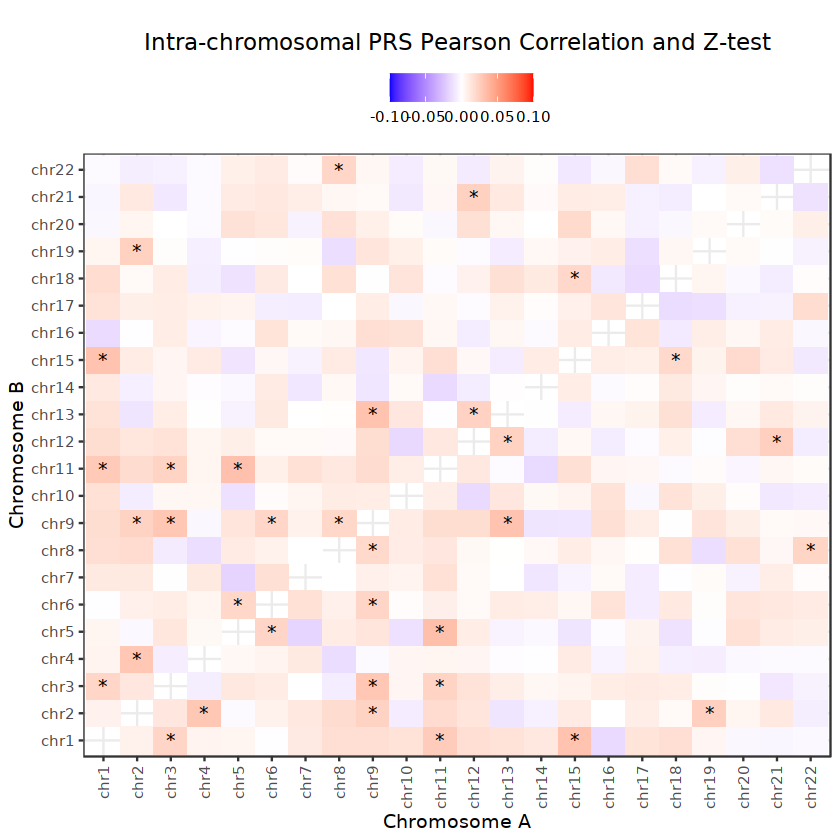

In [168]:
M$col1 <- factor(M$col1, levels = autosomes)
M$col2 <- factor(M$col2, levels = autosomes)
M$labels <- ifelse(M$pvalue < 0.05/(22*11-22), '**', ifelse(M$pvalue < 0.05 , '*',''))
ggplot(M, aes(x=col1, y=col2, fill=mean, label = labels)) +
    geom_tile() +
    geom_text() +
    theme_bw() +
    ylab("Chromosome B") +
    xlab("Chromosome A") +
    labs(fill = "") +
    scale_fill_gradient2(low="blue", mid = 'white', high='red', limits = c(-0.1,0.1)) +
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1),
          legend.position = "top",
          plot.title = element_text(hjust = 0.5)
         ) +
    ggtitle(paste0("\nIntra-chromosomal PRS Pearson Correlation and Z-test"))

In [110]:
fit <- lm(chr11 ~ chr1, data = d)

In [113]:
cor(d$chr11, d$chr1)

[1] 0.01782171

In [33]:
args <- list(
    in_prefix="data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr21_trim"
)


In [37]:
files <- list.files(dirname(args$in_prefix), pattern = basename(args$in_prefix), full.names = TRUE)
files
#files <- files[grepl(".vcf.bgz$", files)]
#files
#stopifnot(length(files) > 0)

[1] "data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr21_trims.txt"

In [21]:
chunks <- stringr::str_extract(files,"[0-9]+of[0-9]+")
chunks <- data.frame(do.call(rbind, strsplit(chunks, "of")))
chunks$X1 <- as.numeric(chunks$X1)
chunks$X2 <- as.numeric(chunks$X2)

In [32]:
stopifnot(length(unique(chunks$X2)) == 1)
stopifnot(length(unique(chunks$X1)) == nrow(chunks))

In [24]:
out <- files[order(chunks$X1)]

In [26]:
paste(out, collapse = " ")

[1] "data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.1of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.2of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.3of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.4of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.5of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.6of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.7of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.8of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.9of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.10of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.11of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.12of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.13of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.14of14.vcf.bgz"